In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import re
import pyabc
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

import sys

sys.path.append("..")
from plotting_tools import * 

In [2]:
plot_path = f"../../plots/example_fits"
os.makedirs(plot_path, exist_ok=True)

result_path = "../../../raw_memilio_data/est_ex"

In [3]:
# ground truth
true_kappa = 0.5
true_init_e = 0.002
true_damp_time = 15
true_damp_lvl = 0.2
# seed for ground truth was 123456789

observed_prev = pd.read_csv(f"{result_path}/ground_truth_comps.csv", delimiter=" ", index_col=False)
observed_prev['prev'] = observed_prev['Ins'] + observed_prev['Isy'] + observed_prev['Isev'] + observed_prev['Icri']
observed_prev = observed_prev[[(x <= 1343) for x in observed_prev["t"]]]
observed_prev['week'] = np.floor(observed_prev['t'] / 24 / 7)

observed_prev = observed_prev.groupby(['week'])['prev'].mean().to_list()

In [4]:
db_path = f"{result_path}/abm.db"
history = pyabc.History("sqlite:///" + db_path)

all_pops = history.get_all_populations()
all_pops = pd.concat([all_pops, all_pops["population_end_time"].shift()], axis=1).dropna()
all_pops.columns = ["t", "end_time", "samples", "epsilon", "particles", "start_time"]
all_pops['diff_minutes'] = (all_pops['end_time'] - all_pops['start_time']).dt.total_seconds() / 60
all_pops['AR'] = all_pops['particles'] / all_pops['samples'] * 100
print(all_pops[['t', "samples", "epsilon", "diff_minutes", "AR"]])

     t  samples     epsilon  diff_minutes         AR
1    0      636  460.734661      0.091188  47.169811
2    1      679  390.855070      0.102856  44.182622
3    2      676  285.999695      0.104182  44.378698
4    3     1553  106.035174      0.220682  19.317450
5    4     1411   80.120822      0.198490  21.261517
6    5     1982   62.136438      0.272735  15.136226
7    6     2538   50.494986      0.338059  11.820331
8    7     2936   40.603555      0.390592  10.217984
9    8     3790   33.724242      0.508530   7.915567
10   9     5254   28.248042      0.707687   5.709935
11  10     5053   23.997781      0.684533   5.937067
12  11    12797   20.257535      1.683125   2.344299
13  12    13552   17.223641      1.788482   2.213695
14  13    17729   15.237781      2.334527   1.692143
15  14    30201   13.012331      3.964791   0.993345
16  15    77450   11.218648     10.232140   0.387347
17  16   110445    9.801308     14.609995   0.271628
18  17   230118    8.734617     30.119715   0.

In [163]:
final_t = 12

In [165]:
dists_by_pop = []
for t in range(final_t + 1):  
    pop = history.get_population(t)
    particles = pop.get_particles_by_model()[0]
    dists = [p.distance for p in particles[:300]]
    dists_by_pop.append(dists)

df_distances = pd.DataFrame(
    [(dist, pop + 1) for pop, dists in enumerate(dists_by_pop) for dist in dists], columns=["distance", "population"])

In [166]:
all_pops_subset = all_pops.loc[all_pops["t"] <= final_t].copy()
all_pops_subset["population"] = all_pops_subset["t"] + 1

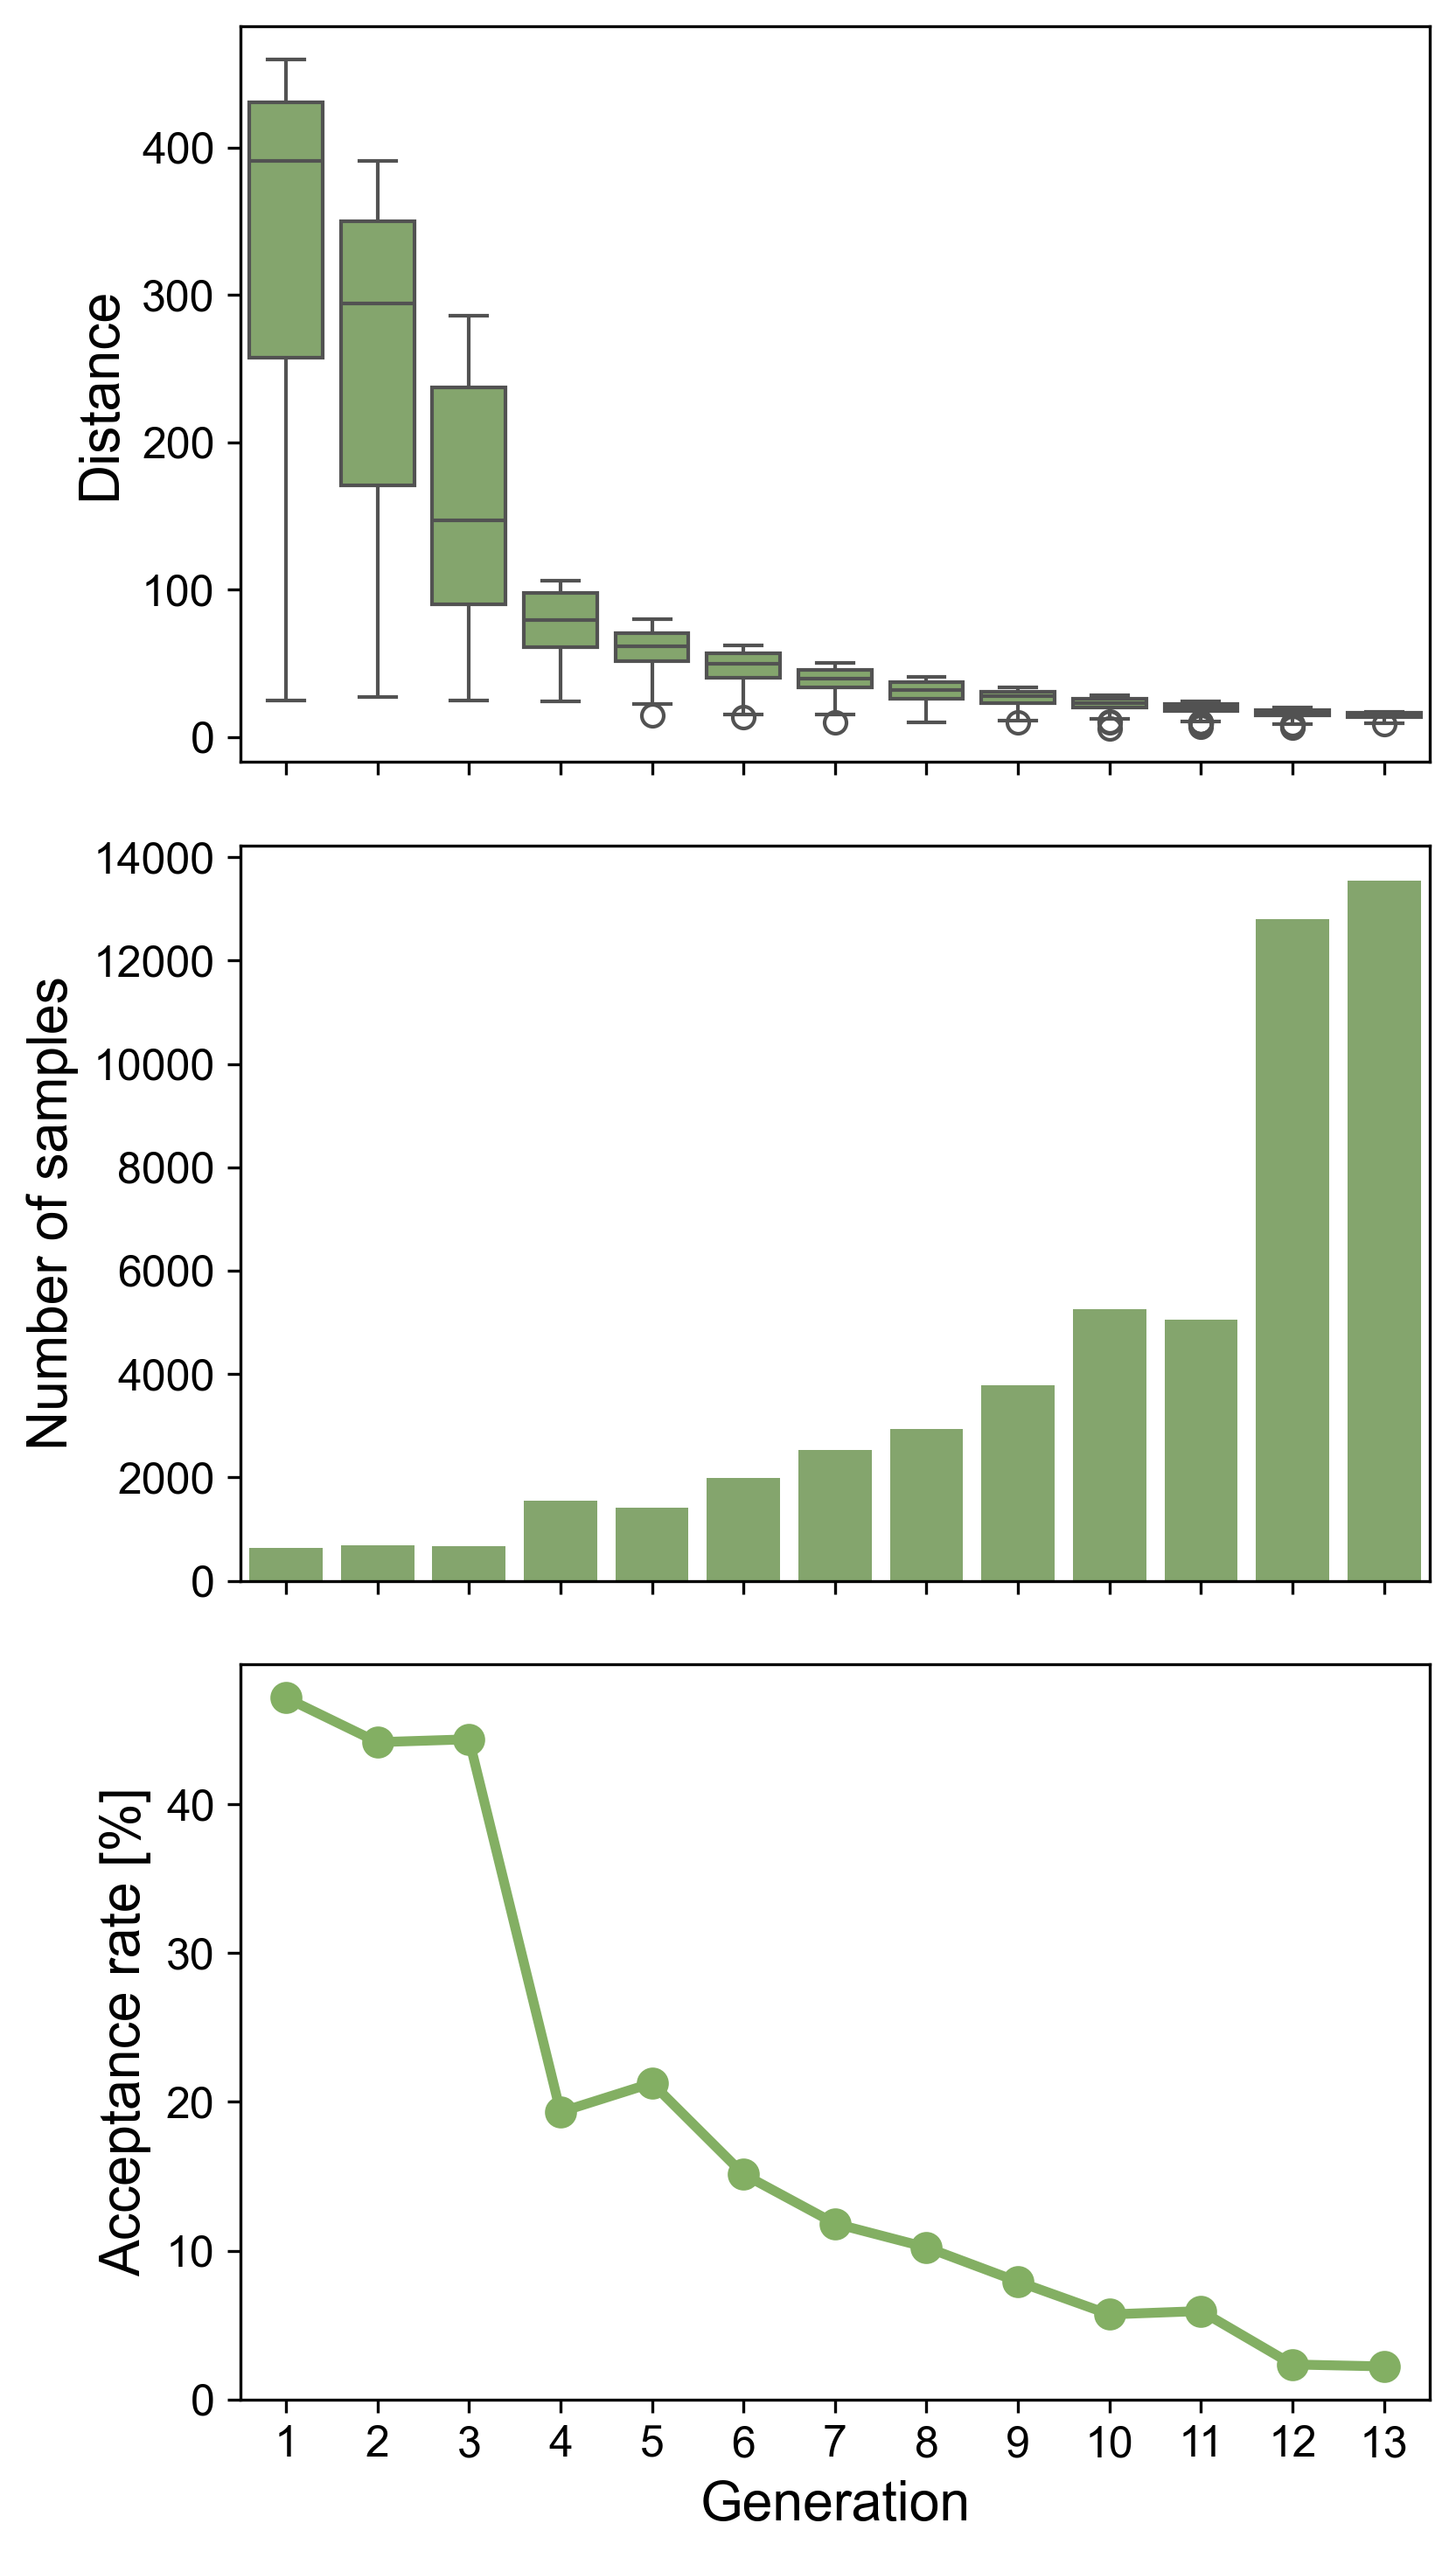

In [167]:
plt.style.use('default')
set_fontsize()

fig, axes = plt.subplots(figsize = (5.8,10), nrows=3, ncols=1, dpi=300)

sns.boxplot(data = df_distances, x = "population", y = "distance", color='#83AF63', ax = axes[0])
axes[0].set_ylabel("Distance")
axes[0].set_xlabel("Generation")
axes[0].set(xlabel = None, xticklabels = [])

sns.barplot(data = all_pops_subset, x = 'population', y = 'samples', color = '#83AF63', ax = axes[1])
axes[1].set_ylabel("Number of samples")
axes[1].set(xlabel = None, xticklabels = [])

sns.pointplot(data=all_pops_subset, x='population', y='AR', ax = axes[2], color = '#83AF63')
axes[2].set_xlabel("Generation")
axes[2].set_ylabel("Acceptance rate [%]")

plt.tight_layout()
plt.savefig(f"{plot_path}/generations.png", dpi=300)
plt.show()

In [168]:
population = history.get_population(final_t)
particle = population.get_particles_by_model()[0]

seeds = []
for i in range(0, 300):
    seeds.append(particle[i].sum_stat["seed"])

In [169]:
def comps_by_week(memilio_id):
    curr_seed = seeds[memilio_id - 1]
    df = pd.read_csv(f"{result_path}/output_comps/{curr_seed}_comps.csv", sep=" ", index_col=False)
    
    df = df[["t", "S", "E", "Ins", "Isy", "Isev", "Icri", "R", "D"]]
    df.columns = [ "time", "S", "E", "I_ns", "I_sy", "I_sev", "I_cri", "R", "D"]
    df["I_total"] = df["I_ns"] + df["I_sy"] + df["I_sev"] + df["I_cri"]
    df["memilio_id"] = memilio_id
    
    df = df[[(x <= 1343) for x in df["time"]]]
    df['week'] = np.floor(df['time'] / 24 / 7)
    df = df.groupby(['week']).agg({'I_total':"mean", "memilio_id":"first"})
    
    return df

In [170]:
fits = [comps_by_week(memilio_id) for memilio_id in range(1, 301)]
fits = pd.concat(fits)
fits['category'] = f"Result (gen. {final_t+1})"

In [171]:
target_data = {'I_total': observed_prev, "memilio_id": [-1] * 8, "category": ["Simulated ground truth"] * 8}
target =  pd.DataFrame(target_data)
fits = pd.concat([fits, target]).reset_index()

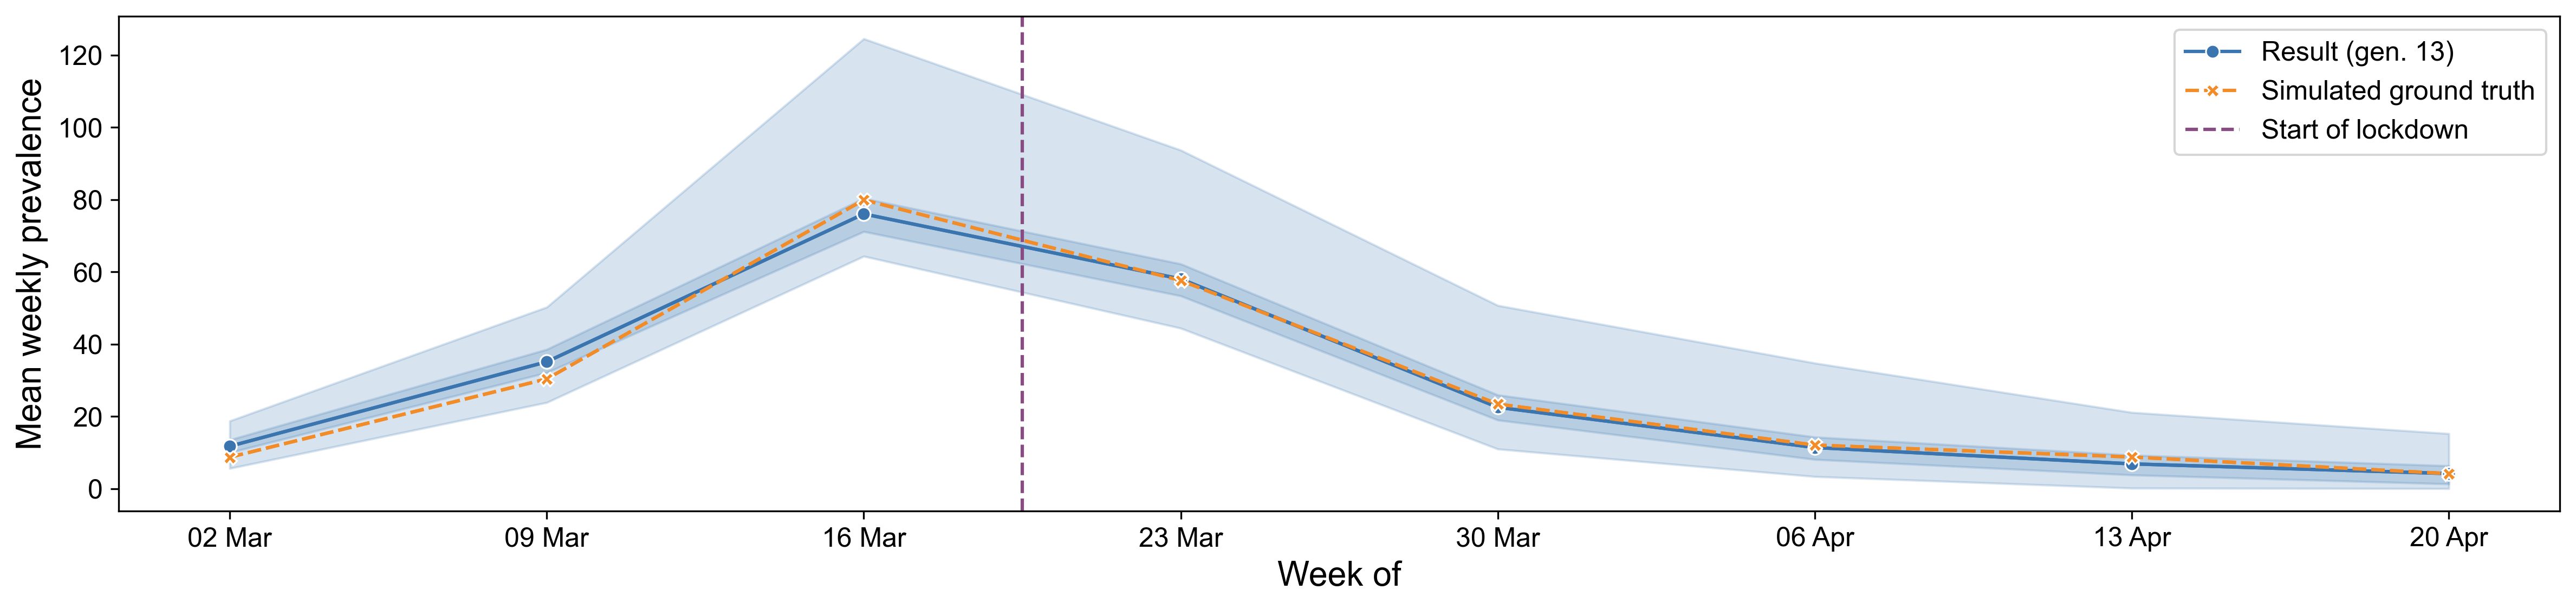

In [172]:
plt.style.use('default')
set_fontsize()

fig, ax = plt.subplots(figsize = (16.1, 4), dpi = 300)

sns.lineplot(data = fits, x="index", y = "I_total", hue = "category", style = "category", palette=['#3B75AF', '#F28C28'], markers = True, errorbar = ("pi", 100))
sns.lineplot(data = fits, x="index", y = "I_total", hue = "category", style = "category", palette=['#3B75AF', '#F28C28'], markers = True, errorbar = ("pi", 50), legend=None)
plt.axvline(2.5, color = "#874C82", linestyle = "--")

ax.set_xlabel("Week of")
ax.set_ylabel("Mean weekly prevalence")
ax.set_xticks(range(0, 8))
ax.set_xticklabels(["02 Mar", "09 Mar", "16 Mar", "23 Mar", "30 Mar", "06 Apr", "13 Apr", "20 Apr"])

handles, labels = ax.get_legend_handles_labels()
line1 = Line2D([0], [0], color="#874C82", linestyle="--", label="Start of lockdown")
handles.extend([line1])
labels.extend(["Start of lockdown"])
ax.legend(handles=handles[0:], labels=labels[0:])

plt.tight_layout()
plt.savefig(f"{plot_path}/prev_fits.png", dpi=300)
plt.show()

In [173]:
def threshold_for_top_mass(post, mass=0.9):
    p = np.asarray(post, dtype=float)
    flat = p.ravel()
    order = np.argsort(flat)[::-1]
    cum_sum = np.cumsum(flat[order])
    k = np.searchsorted(cum_sum, mass, side="left")
    th = flat[order[min(k, len(flat)-1)]]
    return th

def posterior_to_plot_2d(pop_num, x_var, y_var, x_min, x_max, num_x, y_min, y_max, num_y):
    df, w = history.get_distribution(0, pop_num)
    post = pyabc.visualization.kde.kde_2d(df, w, x = x_var, xmin = x_min, xmax = x_max, numx = num_x, 
                                          y = y_var, ymin = y_min, ymax = y_max, numy = num_y)
    post = post[2]
    post = post / sum(sum(post))
    th = threshold_for_top_mass(post, mass=0.9)
    post_mask = (post >= th).astype(float)
    post_mask[post_mask == 0] = np.nan
    post_mask = post_mask[::-1]
    return post_mask

In [174]:
cmap_dict_pop0 = {0: '#FFFFFF', 1: '#eeeeee'}
cmap_pop0 = ListedColormap([cmap_dict_pop0[i] for i in range(2)])

cmap_dict_pop3 = {0: '#FFFFFF', 1: '#cccccc'}
cmap_pop3 = ListedColormap([cmap_dict_pop3[i] for i in range(2)])

cmap_dict_pop6 = {0: '#FFFFFF', 1: '#a2a2a2'}
cmap_pop6 = ListedColormap([cmap_dict_pop6[i] for i in range(2)])

cmap_dict_pop9 = {0: '#FFFFFF', 1: '#595959'}
cmap_pop9 = ListedColormap([cmap_dict_pop9[i] for i in range(2)])

cmap_dict_pop12 = {0: '#FFFFFF', 1: '#3B75AF'}
cmap_pop12 = ListedColormap([cmap_dict_pop12[i] for i in range(2)])

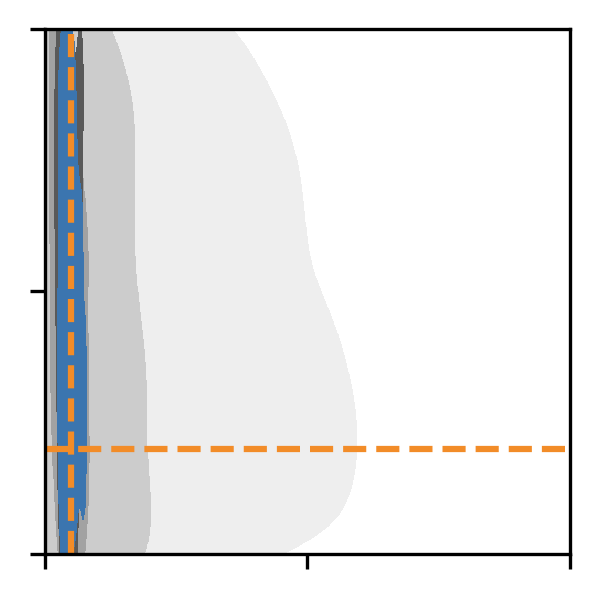

In [175]:
# kappa vs. init_e – ca. 2min to run
pop0_kappa_init_e = posterior_to_plot_2d(pop_num = 0, x_var = "kappa", y_var = "init_e", x_min = 0, x_max = 10, num_x = 1001, y_min = 0, y_max = 0.01, num_y = 1001)
pop3_kappa_init_e = posterior_to_plot_2d(pop_num = 3, x_var = "kappa", y_var = "init_e", x_min = 0, x_max = 10, num_x = 1001, y_min = 0, y_max = 0.01, num_y = 1001)
pop6_kappa_init_e = posterior_to_plot_2d(pop_num = 6, x_var = "kappa", y_var = "init_e", x_min = 0, x_max = 10, num_x = 1001, y_min = 0, y_max = 0.01, num_y = 1001)
pop9_kappa_init_e = posterior_to_plot_2d(pop_num = 9, x_var = "kappa", y_var = "init_e", x_min = 0, x_max = 10, num_x = 1001, y_min = 0, y_max = 0.01, num_y = 1001)
pop12_kappa_init_e = posterior_to_plot_2d(pop_num = 12, x_var = "kappa", y_var = "init_e", x_min = 0, x_max = 10, num_x = 1001, y_min = 0, y_max = 0.01, num_y = 1001)

fig, ax = plt.subplots(figsize = (2.25,2.25), dpi=300) 
set_fontsize()

x_range = np.linspace(0, 10, num = 1001)
y_range = np.linspace(0, 0.01, num = 1001)

sns.heatmap(pop0_kappa_init_e, cmap=cmap_pop0, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop3_kappa_init_e, cmap=cmap_pop3, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop6_kappa_init_e, cmap=cmap_pop6, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop9_kappa_init_e, cmap=cmap_pop9, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop12_kappa_init_e, cmap=cmap_pop12, vmin=0, vmax=1, cbar=False, ax = ax)

x_idx = (true_kappa - x_range[0]) / ((x_range[-1] - x_range[0]) / (len(x_range) - 1)) + 0.5
y_idx = (true_init_e - y_range[0]) / ((y_range[-1] - y_range[0]) / (len(y_range) - 1)) + 0.5
y_idx = (len(y_range) - 1) - y_idx
ax.axvline(x_idx, color="#F28C28", linestyle = "--")
ax.axhline(y_idx, color="#F28C28", linestyle = "--")

ax.set_xticks([0, (len(x_range) - 1) / 2, len(x_range)])
ax.set_yticks([0, (len(y_range) - 1) / 2, len(y_range)])

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.savefig(f"{plot_path}/kappa_init_e.png", dpi=300, bbox_inches="tight")
plt.show()

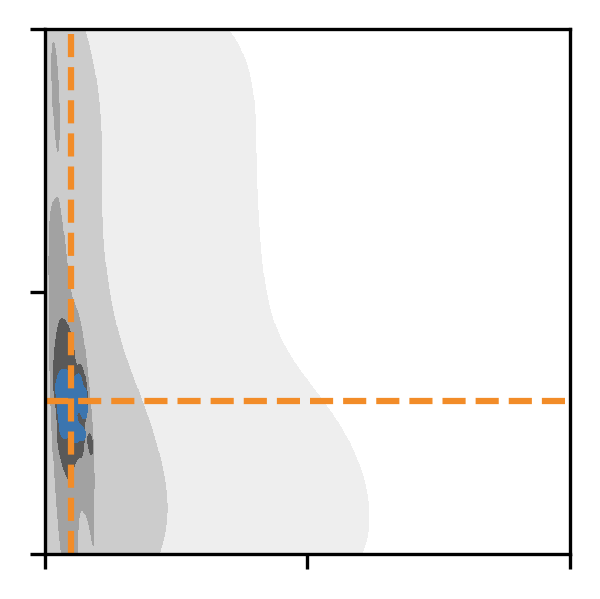

In [176]:
# kappa vs. damp_time – ca. 7min to run
pop0_kappa_damp_time = posterior_to_plot_2d(pop_num = 0, x_var = "kappa", y_var = "damp_time", x_min = 0, x_max = 10, num_x = 1001, y_min = 1, y_max = 49, num_y = 4801)
pop3_kappa_damp_time = posterior_to_plot_2d(pop_num = 3, x_var = "kappa", y_var = "damp_time", x_min = 0, x_max = 10, num_x = 1001, y_min = 1, y_max = 49, num_y = 4801)
pop6_kappa_damp_time = posterior_to_plot_2d(pop_num = 6, x_var = "kappa", y_var = "damp_time", x_min = 0, x_max = 10, num_x = 1001, y_min = 1, y_max = 49, num_y = 4801)
pop9_kappa_damp_time = posterior_to_plot_2d(pop_num = 9, x_var = "kappa", y_var = "damp_time", x_min = 0, x_max = 10, num_x = 1001, y_min = 1, y_max = 49, num_y = 4801)
pop12_kappa_damp_time = posterior_to_plot_2d(pop_num = 12, x_var = "kappa", y_var = "damp_time", x_min = 0, x_max = 10, num_x = 1001, y_min = 1, y_max = 49, num_y = 4801)

fig, ax = plt.subplots(figsize = (2.25,2.25), dpi=300) 
set_fontsize()

x_range = np.linspace(0, 10, num = 1001)
y_range = np.linspace(1, 49, num = 4801)

sns.heatmap(pop0_kappa_damp_time, cmap=cmap_pop0, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop3_kappa_damp_time, cmap=cmap_pop3, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop6_kappa_damp_time, cmap=cmap_pop6, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop9_kappa_damp_time, cmap=cmap_pop9, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop12_kappa_damp_time, cmap=cmap_pop12, vmin=0, vmax=1, cbar=False, ax = ax)

x_idx = (true_kappa - x_range[0]) / ((x_range[-1] - x_range[0]) / (len(x_range) - 1)) + 0.5
y_idx = (true_damp_time - y_range[0]) / ((y_range[-1] - y_range[0]) / (len(y_range) - 1)) + 0.5
y_idx = (len(y_range) - 1) - y_idx
ax.axvline(x_idx, color="#F28C28", linestyle = "--")
ax.axhline(y_idx, color="#F28C28", linestyle = "--")

ax.set_xticks([0, (len(x_range) - 1) / 2, len(x_range)])
ax.set_yticks([0, (len(y_range) - 1) / 2, len(y_range)])

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.savefig(f"{plot_path}/kappa_damp_time.png", dpi=300, bbox_inches="tight")
plt.show()

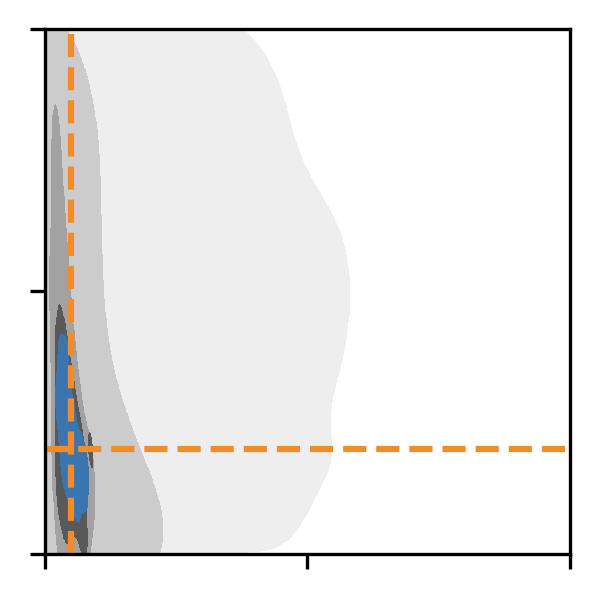

In [177]:
# kappa vs. damp_lvl – ca. 1.5min to run 
pop0_kappa_damp_lvl = posterior_to_plot_2d(pop_num = 0, x_var = "kappa", y_var = "damp_lvl", x_min = 0, x_max = 10, num_x = 1001, y_min = 0, y_max = 1, num_y = 1001)
pop3_kappa_damp_lvl = posterior_to_plot_2d(pop_num = 3, x_var = "kappa", y_var = "damp_lvl", x_min = 0, x_max = 10, num_x = 1001, y_min = 0, y_max = 1, num_y = 1001)
pop6_kappa_damp_lvl = posterior_to_plot_2d(pop_num = 6, x_var = "kappa", y_var = "damp_lvl", x_min = 0, x_max = 10, num_x = 1001, y_min = 0, y_max = 1, num_y = 1001)
pop9_kappa_damp_lvl = posterior_to_plot_2d(pop_num = 9, x_var = "kappa", y_var = "damp_lvl", x_min = 0, x_max = 10, num_x = 1001, y_min = 0, y_max = 1, num_y = 1001)
pop12_kappa_damp_lvl = posterior_to_plot_2d(pop_num = 12, x_var = "kappa", y_var = "damp_lvl", x_min = 0, x_max = 10, num_x = 1001, y_min = 0, y_max = 1, num_y = 1001)

fig, ax = plt.subplots(figsize = (2.25,2.25), dpi=300) 
set_fontsize()

x_range = np.linspace(0, 10, num = 1001)
y_range = np.linspace(0, 1, num = 1001)

sns.heatmap(pop0_kappa_damp_lvl, cmap=cmap_pop0, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop3_kappa_damp_lvl, cmap=cmap_pop3, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop6_kappa_damp_lvl, cmap=cmap_pop6, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop9_kappa_damp_lvl, cmap=cmap_pop9, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop12_kappa_damp_lvl, cmap=cmap_pop12, vmin=0, vmax=1, cbar=False, ax = ax)

x_idx = (true_kappa - x_range[0]) / ((x_range[-1] - x_range[0]) / (len(x_range) - 1)) + 0.5
y_idx = (true_damp_lvl - y_range[0]) / ((y_range[-1] - y_range[0]) / (len(y_range) - 1)) + 0.5
y_idx = (len(y_range) - 1) - y_idx
ax.axvline(x_idx, color="#F28C28", linestyle = "--")
ax.axhline(y_idx, color="#F28C28", linestyle = "--")

ax.set_xticks([0, (len(x_range) - 1) / 2, len(x_range)])
ax.set_yticks([0, (len(y_range) - 1) / 2, len(y_range)])

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.savefig(f"{plot_path}/kappa_damp_lvl.png", dpi=300, bbox_inches="tight")
plt.show()

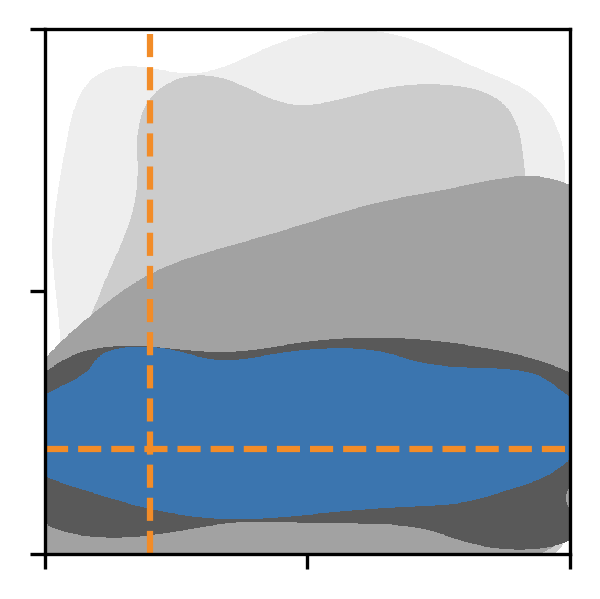

In [178]:
# init_e vs. damp_lvl – ca. 2min to run
pop0_init_e_damp_lvl = posterior_to_plot_2d(pop_num = 0, x_var = "init_e", y_var = "damp_lvl", x_min = 0, x_max = 0.01, num_x = 1001, y_min = 0, y_max = 1, num_y = 1001)
pop3_init_e_damp_lvl = posterior_to_plot_2d(pop_num = 3, x_var = "init_e", y_var = "damp_lvl", x_min = 0, x_max = 0.01, num_x = 1001, y_min = 0, y_max = 1, num_y = 1001)
pop6_init_e_damp_lvl = posterior_to_plot_2d(pop_num = 6, x_var = "init_e", y_var = "damp_lvl", x_min = 0, x_max = 0.01, num_x = 1001, y_min = 0, y_max = 1, num_y = 1001)
pop9_init_e_damp_lvl = posterior_to_plot_2d(pop_num = 9, x_var = "init_e", y_var = "damp_lvl", x_min = 0, x_max = 0.01, num_x = 1001, y_min = 0, y_max = 1, num_y = 1001)
pop12_init_e_damp_lvl = posterior_to_plot_2d(pop_num = 12, x_var = "init_e", y_var = "damp_lvl", x_min = 0, x_max = 0.01, num_x = 1001, y_min = 0, y_max = 1, num_y = 1001)

fig, ax = plt.subplots(figsize = (2.25,2.25), dpi=300) 
set_fontsize()

x_range = np.linspace(0, 0.01, num = 1001)
y_range = np.linspace(0, 1, num = 1001)

sns.heatmap(pop0_init_e_damp_lvl, cmap=cmap_pop0, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop3_init_e_damp_lvl, cmap=cmap_pop3, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop6_init_e_damp_lvl, cmap=cmap_pop6, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop9_init_e_damp_lvl, cmap=cmap_pop9, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop12_init_e_damp_lvl, cmap=cmap_pop12, vmin=0, vmax=1, cbar=False, ax = ax)

x_idx = (true_init_e - x_range[0]) / ((x_range[-1] - x_range[0]) / (len(x_range) - 1)) + 0.5
y_idx = (true_damp_lvl - y_range[0]) / ((y_range[-1] - y_range[0]) / (len(y_range) - 1)) + 0.5
y_idx = (len(y_range) - 1) - y_idx
ax.axvline(x_idx, color="#F28C28", linestyle = "--")
ax.axhline(y_idx, color="#F28C28", linestyle = "--")

ax.set_xticks([0, (len(x_range) - 1) / 2, len(x_range)])
ax.set_yticks([0, (len(y_range) - 1) / 2, len(y_range)])

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.savefig(f"{plot_path}/init_e_damp_lvl.png", dpi=300, bbox_inches="tight")
plt.show()

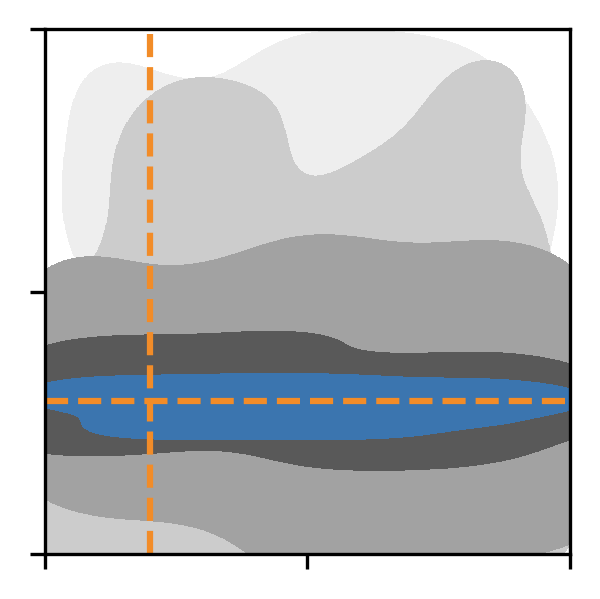

In [179]:
# init_e vs. damp_time – ca. 8min to run
pop0_init_e_damp_time = posterior_to_plot_2d(pop_num = 0, x_var = "init_e", y_var = "damp_time", x_min = 0, x_max = 0.01, num_x = 1001, y_min = 1, y_max = 49, num_y = 4801)
pop3_init_e_damp_time = posterior_to_plot_2d(pop_num = 3, x_var = "init_e", y_var = "damp_time", x_min = 0, x_max = 0.01, num_x = 1001, y_min = 1, y_max = 49, num_y = 4801)
pop6_init_e_damp_time = posterior_to_plot_2d(pop_num = 6, x_var = "init_e", y_var = "damp_time", x_min = 0, x_max = 0.01, num_x = 1001, y_min = 1, y_max = 49, num_y = 4801)
pop9_init_e_damp_time = posterior_to_plot_2d(pop_num = 9, x_var = "init_e", y_var = "damp_time", x_min = 0, x_max = 0.01, num_x = 1001, y_min = 1, y_max = 49, num_y = 4801)
pop12_init_e_damp_time = posterior_to_plot_2d(pop_num = 12, x_var = "init_e", y_var = "damp_time", x_min = 0, x_max = 0.01, num_x = 1001, y_min = 1, y_max = 49, num_y = 4801)

fig, ax = plt.subplots(figsize = (2.25,2.25), dpi=300) 
set_fontsize()

x_range = np.linspace(0, 0.01, num = 1001)
y_range = np.linspace(1, 49, num = 4801)

sns.heatmap(pop0_init_e_damp_time, cmap=cmap_pop0, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop3_init_e_damp_time, cmap=cmap_pop3, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop6_init_e_damp_time, cmap=cmap_pop6, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop9_init_e_damp_time, cmap=cmap_pop9, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop12_init_e_damp_time, cmap=cmap_pop12, vmin=0, vmax=1, cbar=False, ax = ax)

x_idx = (true_init_e - x_range[0]) / ((x_range[-1] - x_range[0]) / (len(x_range) - 1)) + 0.5
y_idx = (true_damp_time - y_range[0]) / ((y_range[-1] - y_range[0]) / (len(y_range) - 1)) + 0.5
y_idx = (len(y_range) - 1) - y_idx
ax.axvline(x_idx, color="#F28C28", linestyle = "--")
ax.axhline(y_idx, color="#F28C28", linestyle = "--")

ax.set_xticks([0, (len(x_range) - 1) / 2, len(x_range)])
ax.set_yticks([0, (len(y_range) - 1) / 2, len(y_range)])

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.savefig(f"{plot_path}/init_e_damp_time.png", dpi=300, bbox_inches="tight")
plt.show()

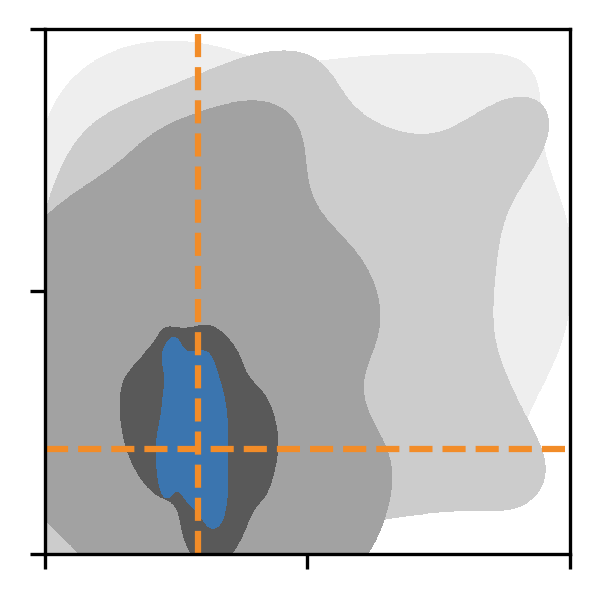

In [180]:
# damp_time vs. damp_lvl – ca. 7min to run
pop0_damp_time_damp_lvl = posterior_to_plot_2d(pop_num = 0, x_var = "damp_time", y_var = "damp_lvl", x_min = 1, x_max = 49, num_x = 4801, y_min = 0, y_max = 1, num_y = 1001)
pop3_damp_time_damp_lvl = posterior_to_plot_2d(pop_num = 3, x_var = "damp_time", y_var = "damp_lvl", x_min = 1, x_max = 49, num_x = 4801, y_min = 0, y_max = 1, num_y = 1001)
pop6_damp_time_damp_lvl = posterior_to_plot_2d(pop_num = 6, x_var = "damp_time", y_var = "damp_lvl", x_min = 1, x_max = 49, num_x = 4801, y_min = 0, y_max = 1, num_y = 1001)
pop9_damp_time_damp_lvl = posterior_to_plot_2d(pop_num = 9, x_var = "damp_time", y_var = "damp_lvl", x_min = 1, x_max = 49, num_x = 4801, y_min = 0, y_max = 1, num_y = 1001)
pop12_damp_time_damp_lvl = posterior_to_plot_2d(pop_num = 12, x_var = "damp_time", y_var = "damp_lvl", x_min = 1, x_max = 49, num_x = 4801, y_min = 0, y_max = 1, num_y = 1001)

fig, ax = plt.subplots(figsize = (2.25,2.25), dpi=300) 
set_fontsize()

x_range = np.linspace(1, 49, num = 4801)
y_range = np.linspace(0, 1, num = 1001)

sns.heatmap(pop0_damp_time_damp_lvl, cmap=cmap_pop0, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop3_damp_time_damp_lvl, cmap=cmap_pop3, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop6_damp_time_damp_lvl, cmap=cmap_pop6, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop9_damp_time_damp_lvl, cmap=cmap_pop9, vmin=0, vmax=1, cbar=False, ax = ax)
sns.heatmap(pop12_damp_time_damp_lvl, cmap=cmap_pop12, vmin=0, vmax=1, cbar=False, ax = ax)

x_idx = (true_damp_time - x_range[0]) / ((x_range[-1] - x_range[0]) / (len(x_range) - 1)) + 0.5
y_idx = (true_damp_lvl - y_range[0]) / ((y_range[-1] - y_range[0]) / (len(y_range) - 1)) + 0.5
y_idx = (len(y_range) - 1) - y_idx
ax.axvline(x_idx, color="#F28C28", linestyle = "--")
ax.axhline(y_idx, color="#F28C28", linestyle = "--")

ax.set_xticks([0, (len(x_range) - 1) / 2, len(x_range)])
ax.set_yticks([0, (len(y_range) - 1) / 2, len(y_range)])

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.savefig(f"{plot_path}/damp_time_damp_lvl.png", dpi=300, bbox_inches="tight")
plt.show()

In [181]:
def posterior_to_plot_1d(pop_num, x_var, x_min, x_max, num_x):
    df, w = history.get_distribution(0, pop_num)
    post = pyabc.visualization.kde.kde_1d(df, w, x = x_var, xmin = x_min, xmax = x_max, numx = num_x)
    post_list = list(map(list, zip(*list(post))))
    return pd.DataFrame(post_list, columns = ["x", "prob"])

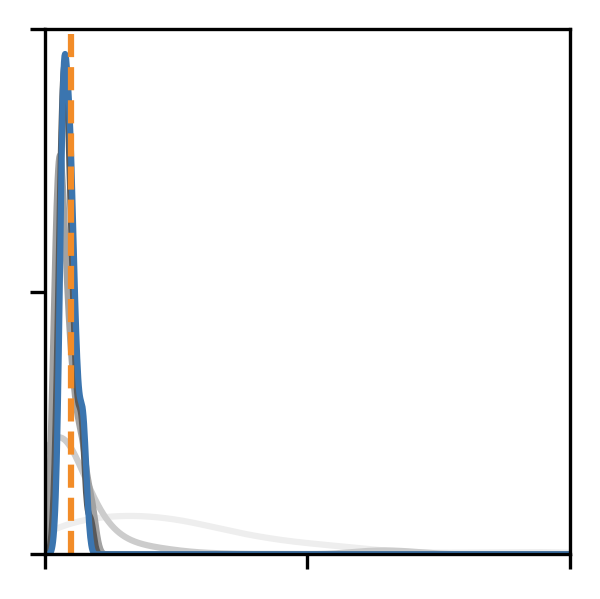

In [182]:
pop0_kappa = posterior_to_plot_1d(pop_num = 0, x_var = "kappa", x_min = 0, x_max = 10, num_x = 1001)
pop3_kappa = posterior_to_plot_1d(pop_num = 3, x_var = "kappa", x_min = 0, x_max = 10, num_x = 1001)
pop6_kappa = posterior_to_plot_1d(pop_num = 6, x_var = "kappa", x_min = 0, x_max = 10, num_x = 1001)
pop9_kappa = posterior_to_plot_1d(pop_num = 9, x_var = "kappa", x_min = 0, x_max = 10, num_x = 1001)
pop12_kappa = posterior_to_plot_1d(pop_num = 12, x_var = "kappa", x_min = 0, x_max = 10, num_x = 1001)

fig, ax = plt.subplots(figsize = (2.25,2.25), dpi=300) 
set_fontsize()

dfs = [pop0_kappa, pop3_kappa, pop6_kappa, pop9_kappa, pop12_kappa]
max_y = max(df['prob'].max() for df in dfs) * 1.05

sns.lineplot(pop0_kappa, x = "x", y = "prob", color = '#eeeeee', ax = ax)
sns.lineplot(pop3_kappa, x = "x", y = "prob", color = '#cccccc', ax = ax)
sns.lineplot(pop6_kappa, x = "x", y = "prob", color = '#a2a2a2', ax = ax)
sns.lineplot(pop9_kappa, x = "x", y = "prob", color = '#595959', ax = ax)
sns.lineplot(pop12_kappa, x = "x", y = "prob", color = '#3b75af', ax = ax)
plt.axvline(true_kappa, 0, 1e3, color = "#F28C28", linestyle = "--")

ax.set(ylim=(0, max_y))
ax.set_yticks([0, max_y / 2, max_y])
ax.set(xlabel = None, ylabel = None, xticklabels = [], yticklabels = [])

for spine in ax.spines.values():
    spine.set_visible(True)

ax.margins(x=0, y=0)
plt.tight_layout()
plt.savefig(f"{plot_path}/kappa.png", dpi=300, bbox_inches="tight")
plt.show()

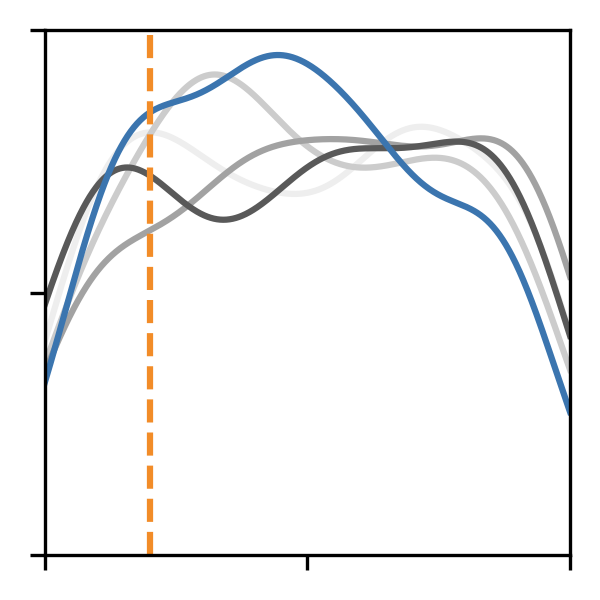

In [183]:
pop0_init_e = posterior_to_plot_1d(pop_num = 0, x_var = "init_e", x_min = 0, x_max = 0.01, num_x = 1001)
pop3_init_e = posterior_to_plot_1d(pop_num = 3, x_var = "init_e", x_min = 0, x_max = 0.01, num_x = 1001)
pop6_init_e = posterior_to_plot_1d(pop_num = 6, x_var = "init_e", x_min = 0, x_max = 0.01, num_x = 1001)
pop9_init_e = posterior_to_plot_1d(pop_num = 9, x_var = "init_e", x_min = 0, x_max = 0.01, num_x = 1001)
pop12_init_e = posterior_to_plot_1d(pop_num = 12, x_var = "init_e", x_min = 0, x_max = 0.01, num_x = 1001)

fig, ax = plt.subplots(figsize = (2.25,2.25), dpi=300) 
set_fontsize()

dfs = [pop0_init_e, pop3_init_e, pop6_init_e, pop9_init_e, pop12_init_e]
max_y = max(df['prob'].max() for df in dfs) * 1.05

sns.lineplot(pop0_init_e, x = "x", y = "prob", color = '#eeeeee', ax = ax)
sns.lineplot(pop3_init_e, x = "x", y = "prob", color = '#cccccc', ax = ax)
sns.lineplot(pop6_init_e, x = "x", y = "prob", color = '#a2a2a2', ax = ax)
sns.lineplot(pop9_init_e, x = "x", y = "prob", color = '#595959', ax = ax)
sns.lineplot(pop12_init_e, x = "x", y = "prob", color = '#3b75af', ax = ax)
plt.axvline(true_init_e, 0, 1e3, color = "#F28C28", linestyle = "--")

ax.set(ylim=(0, max_y))
ax.set_yticks([0, max_y / 2, max_y])
ax.set(xlabel = None, ylabel = None, xticklabels = [], yticklabels = [])

for spine in ax.spines.values():
    spine.set_visible(True)

ax.margins(x=0, y=0)
plt.tight_layout()
plt.savefig(f"{plot_path}/init_e.png", dpi=300, bbox_inches="tight")
plt.show()

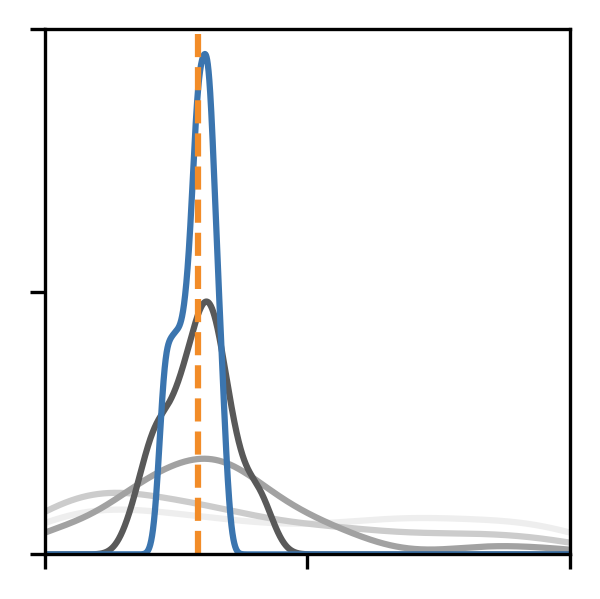

In [184]:
pop0_damp_time = posterior_to_plot_1d(pop_num = 0, x_var = "damp_time", x_min = 1, x_max = 49, num_x = 4801)
pop3_damp_time = posterior_to_plot_1d(pop_num = 3, x_var = "damp_time", x_min = 1, x_max = 49, num_x = 4801)
pop6_damp_time = posterior_to_plot_1d(pop_num = 6, x_var = "damp_time", x_min = 1, x_max = 49, num_x = 4801)
pop9_damp_time = posterior_to_plot_1d(pop_num = 9, x_var = "damp_time", x_min = 1, x_max = 49, num_x = 4801)
pop12_damp_time = posterior_to_plot_1d(pop_num = 12, x_var = "damp_time", x_min = 1, x_max = 49, num_x = 4801)

fig, ax = plt.subplots(figsize = (2.25,2.25), dpi=300) 
set_fontsize()

dfs = [pop0_damp_time, pop3_damp_time, pop6_damp_time, pop9_damp_time, pop12_damp_time]
max_y = max(df['prob'].max() for df in dfs) * 1.05

sns.lineplot(pop0_damp_time, x = "x", y = "prob", color = '#eeeeee', ax = ax)
sns.lineplot(pop3_damp_time, x = "x", y = "prob", color = '#cccccc', ax = ax)
sns.lineplot(pop6_damp_time, x = "x", y = "prob", color = '#a2a2a2', ax = ax)
sns.lineplot(pop9_damp_time, x = "x", y = "prob", color = '#595959', ax = ax)
sns.lineplot(pop12_damp_time, x = "x", y = "prob", color = '#3b75af', ax = ax)
plt.axvline(true_damp_time, 0, 1e3, color = "#F28C28", linestyle = "--")

ax.set(ylim=(0, max_y))
ax.set_yticks([0, max_y / 2, max_y])
ax.set_xticks([1, 25, 49])
ax.set(xlabel = None, ylabel = None, xticklabels = [], yticklabels = [])

for spine in ax.spines.values():
    spine.set_visible(True)

ax.margins(x=0, y=0)
plt.tight_layout()
plt.savefig(f"{plot_path}/damp_time.png", dpi=300, bbox_inches="tight")
plt.show()

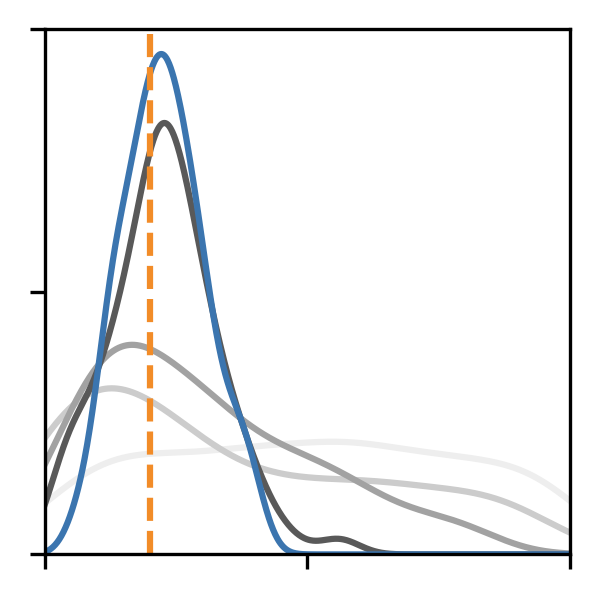

In [185]:
pop0_damp_lvl = posterior_to_plot_1d(pop_num = 0, x_var = "damp_lvl", x_min = 0, x_max = 1, num_x = 1001)
pop3_damp_lvl = posterior_to_plot_1d(pop_num = 3, x_var = "damp_lvl", x_min = 0, x_max = 1, num_x = 1001)
pop6_damp_lvl = posterior_to_plot_1d(pop_num = 6, x_var = "damp_lvl", x_min = 0, x_max = 1, num_x = 1001)
pop9_damp_lvl = posterior_to_plot_1d(pop_num = 9, x_var = "damp_lvl", x_min = 0, x_max = 1, num_x = 1001)
pop12_damp_lvl = posterior_to_plot_1d(pop_num = 12, x_var = "damp_lvl", x_min = 0, x_max = 1, num_x = 1001)

fig, ax = plt.subplots(figsize = (2.25,2.25), dpi=300) 
set_fontsize()

dfs = [pop0_damp_lvl, pop3_damp_lvl, pop6_damp_lvl, pop9_damp_lvl, pop12_damp_lvl]
max_y = max(df['prob'].max() for df in dfs) * 1.05

sns.lineplot(pop0_damp_lvl, x = "x", y = "prob", color = '#eeeeee', ax = ax)
sns.lineplot(pop3_damp_lvl, x = "x", y = "prob", color = '#cccccc', ax = ax)
sns.lineplot(pop6_damp_lvl, x = "x", y = "prob", color = '#a2a2a2', ax = ax)
sns.lineplot(pop9_damp_lvl, x = "x", y = "prob", color = '#595959', ax = ax)
sns.lineplot(pop12_damp_lvl, x = "x", y = "prob", color = '#3b75af', ax = ax)
plt.axvline(true_damp_lvl, 0, 1e3, color = "#F28C28", linestyle = "--")

ax.set(ylim=(0, max_y))
ax.set_yticks([0, max_y / 2, max_y])
ax.set(xlabel = None, ylabel = None, xticklabels = [], yticklabels = [])

for spine in ax.spines.values():
    spine.set_visible(True)

ax.margins(x=0, y=0)
plt.tight_layout()
plt.savefig(f"{plot_path}/damp_lvl.png", dpi=300, bbox_inches="tight")
plt.show()